# Tâche 3 : Interprétabilité avec SHAP
## Dataset : German Credit (UCI)

**Objectif** : Expliquer les prédictions du modèle XGBoost baseline avec SHAP, et analyser le lien entre les features importantes et les disparités d'équité observées en Tâche 2.

### Pourquoi `TreeExplainer` ?

`shap.TreeExplainer` exploite la structure des arbres de décision pour calculer les SHAP values **exactes** (pas d'approximation Monte-Carlo). Sa complexité est O(T × L × D²) au lieu de O(2^D) par force brute, où T = nombre d'arbres, L = feuilles, D = profondeur. Pour XGBoost avec 200 arbres, c'est très rapide.

**4 analyses** :
1. Summary plot : importance globale + direction des effets
2. Waterfall plot : explication d'un refus individuel
3. Dependence plot : interaction `age` et `checking_account`
4. Lien SHAP / équité : les features sensibles influencent-elles le modèle ?

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
shap.initjs()
print("Imports OK")

Imports OK


## 2. Chargement et prétraitement (identique au baseline)

In [2]:
col_names = [
    "checking_account", "duration", "credit_history", "purpose",
    "credit_amount", "savings_account", "employment_since",
    "installment_rate", "personal_status_sex", "other_debtors",
    "residence_since", "property", "age", "other_installment",
    "housing", "existing_credits", "job", "liable_people",
    "telephone", "foreign_worker", "credit_risk"
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
df = pd.read_csv(url, sep=" ", header=None, names=col_names)

df["target"] = (df["credit_risk"] == 2).astype(int)

sex_map = {"A91": "Homme", "A92": "Femme", "A93": "Homme", "A94": "Homme", "A95": "Femme"}
df["gender"]    = df["personal_status_sex"].map(sex_map)
df["age_group"] = (df["age"] < 25).map({True: "Jeune (<25)", False: "Senior (>=25)"})

cat_cols = [
    "checking_account", "credit_history", "purpose", "savings_account",
    "employment_since", "personal_status_sex", "other_debtors", "property",
    "other_installment", "housing", "job", "telephone", "foreign_worker"
]
df_encoded = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

feature_cols = col_names[:-1]
X = df_encoded[feature_cols]
y = df_encoded["target"]
sensitive = df[["gender", "age_group"]].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
sensitive_test = sensitive.loc[X_test.index].reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")

Train : 800 | Test : 200


## 3. Entraînement du modèle XGBoost baseline

In [3]:
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio,
    eval_metric="logloss", random_state=RANDOM_STATE,
    use_label_encoder=False,
)
model.fit(X_train, y_train)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f} | "
      f"F1 : {f1_score(y_test, y_pred):.4f} | "
      f"AUC : {roc_auc_score(y_test, y_proba):.4f}")

Accuracy : 0.7750 | F1 : 0.6400 | AUC : 0.8042


## 4. Calcul des SHAP values avec TreeExplainer

`shap.TreeExplainer(model)` est l'explainer exact pour les modèles basés sur des arbres (XGBoost, LightGBM, Random Forest). Il utilise l'algorithme TreeSHAP qui calcule les valeurs SHAP exactes en temps polynomial grâce à la structure des arbres, contrairement à l'approche naïve qui est exponentielle.

La SHAP value `φ_i(x)` d'une feature `i` pour une instance `x` représente la **contribution marginale moyenne** de cette feature à la prédiction, en moyenne sur toutes les permutations possibles de features.

In [4]:
# TreeExplainer : exact et rapide pour XGBoost
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)  # shape : (n_test, n_features)

print(f"SHAP values shape : {shap_values.shape}")
print(f"Valeur de base (expected value) : {explainer.expected_value:.4f}")
print("Interprétation : prédiction = valeur_de_base + somme des SHAP values")

SHAP values shape : (200, 20)
Valeur de base (expected value) : 0.2406
Interprétation : prédiction = valeur_de_base + somme des SHAP values


## 5. Summary Plot : Importance globale et direction des effets

Chaque point représente un individu du test set.
- **Axe X** : valeur SHAP, contribution à la prédiction (positif = augmente le risque de mauvais crédit)
- **Couleur** : valeur de la feature (rouge = haute, bleu = basse)
- **Ordre** : features triées par importance moyenne (|SHAP|)

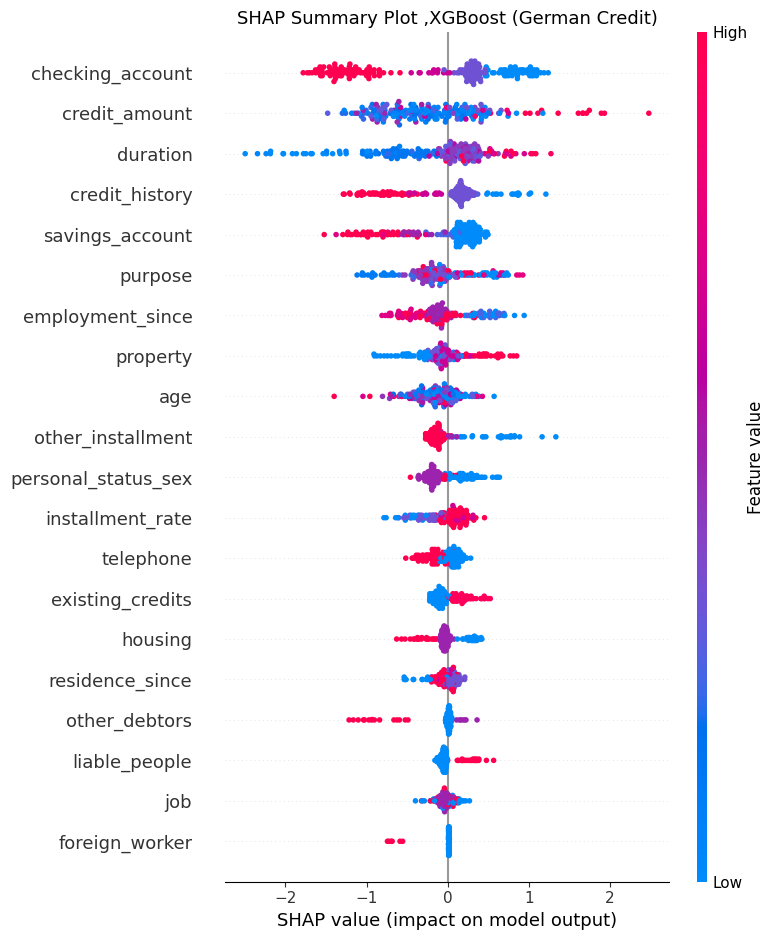

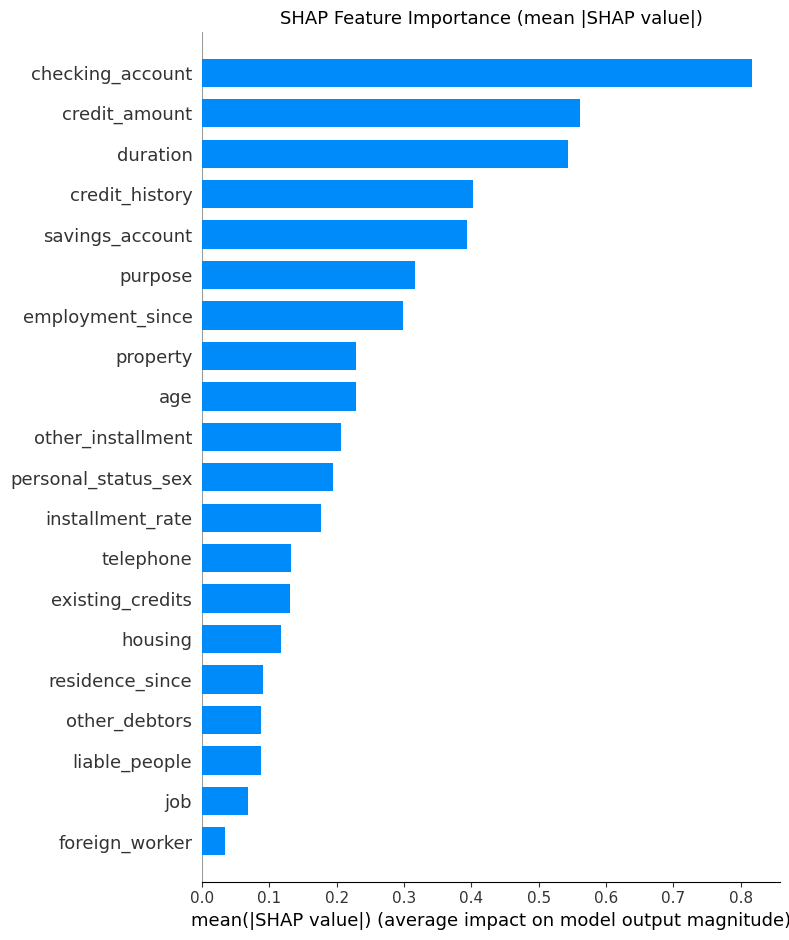

=== Importance SHAP moyenne (|valeur SHAP|) ===
checking_account       0.8176
credit_amount          0.5616
duration               0.5431
credit_history         0.4024
savings_account        0.3941
purpose                0.3157
employment_since       0.2985
property               0.2292
age                    0.2290
other_installment      0.2056
personal_status_sex    0.1946
installment_rate       0.1770
telephone              0.1323
existing_credits       0.1309
housing                0.1171
residence_since        0.0909
other_debtors          0.0879
liable_people          0.0874
job                    0.0688
foreign_worker         0.0338


In [ ]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title("SHAP Summary Plot, XGBoost (German Credit)", fontsize=13)
plt.tight_layout()
plt.show()

# Bar plot : importance moyenne |SHAP|
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance (mean |SHAP value|)", fontsize=13)
plt.tight_layout()
plt.show()

# Tableau numérique de l'importance SHAP
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols)
mean_shap = mean_shap.sort_values(ascending=False)
print("=== Importance SHAP moyenne (|valeur SHAP|) ===")
print(mean_shap.round(4).to_string())

## 6. Waterfall Plot : Explication d'un refus individuel

On choisit un individu prédit comme **mauvais crédit** (classe 1) et on décompose sa prédiction feature par feature.

Le waterfall plot montre comment chaque feature pousse la prédiction **au-dessus ou en-dessous** de la valeur de base du modèle.

Individu sélectionné : index 2
  Probabilité prédite (mauvais crédit) : 0.8788
  Vraie étiquette : Mauvais crédit
  Âge : 48 ans
  Genre : Homme


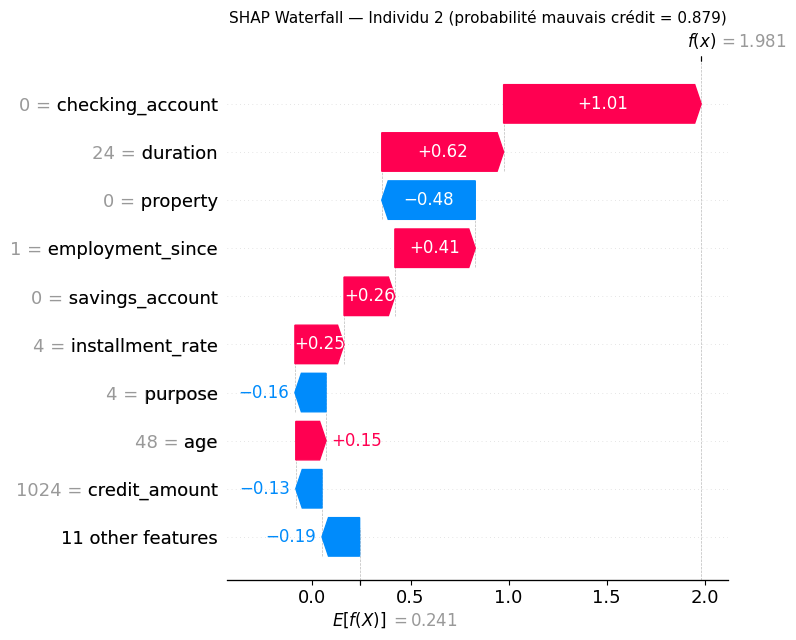

In [ ]:
# Sélectionner un individu prédit mauvais crédit avec forte probabilité
y_pred_test = model.predict(X_test)
candidates  = np.where((y_pred_test == 1) & (y_proba > 0.7))[0]
idx_case    = candidates[0] if len(candidates) > 0 else np.argmax(y_proba)

print(f"Individu sélectionné : index {idx_case}")
print(f"  Probabilité prédite (mauvais crédit) : {y_proba[idx_case]:.4f}")
print(f"  Vraie étiquette : {'Mauvais crédit' if y_test.iloc[idx_case] == 1 else 'Bon crédit'}")
print(f"  Âge : {X_test.iloc[idx_case]['age']} ans")
print(f"  Genre : {sensitive_test.iloc[idx_case]['gender']}")

# Waterfall plot via shap.Explanation
shap_explanation = shap.Explanation(
    values       = shap_values[idx_case],
    base_values  = explainer.expected_value,
    data         = X_test.iloc[idx_case].values,
    feature_names= feature_cols
)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation, show=False)
plt.title(f"SHAP Waterfall, Individu {idx_case} (probabilité mauvais crédit = {y_proba[idx_case]:.3f})",
          fontsize=11)
plt.tight_layout()
plt.show()

Individu bon crédit sélectionné : index 0
  Probabilité prédite (mauvais crédit) : 0.1647
  Âge : 36 ans | Genre : Homme


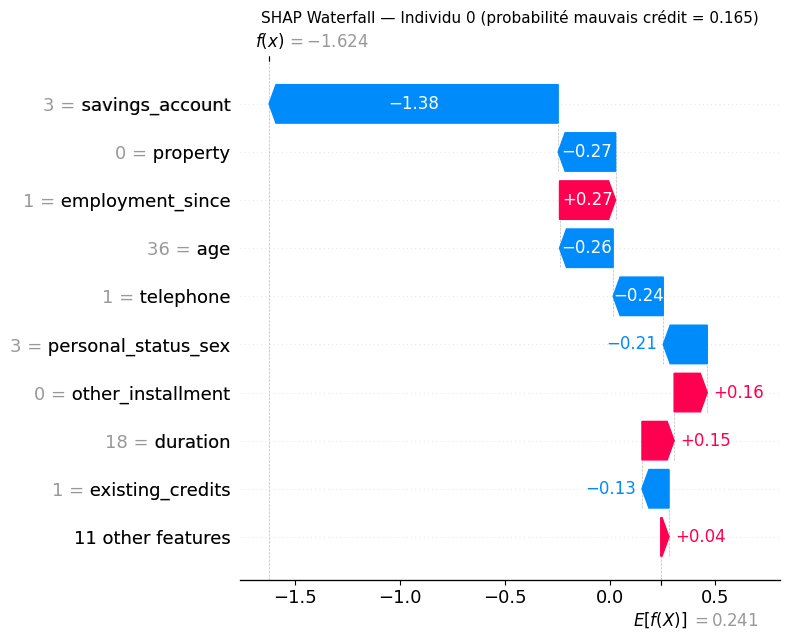

In [ ]:
# Comparer avec un individu prédit bon crédit
candidates_good = np.where((y_pred_test == 0) & (y_proba < 0.2))[0]
idx_good = candidates_good[0] if len(candidates_good) > 0 else np.argmin(y_proba)

print(f"Individu bon crédit sélectionné : index {idx_good}")
print(f"  Probabilité prédite (mauvais crédit) : {y_proba[idx_good]:.4f}")
print(f"  Âge : {X_test.iloc[idx_good]['age']} ans | Genre : {sensitive_test.iloc[idx_good]['gender']}")

shap_explanation_good = shap.Explanation(
    values       = shap_values[idx_good],
    base_values  = explainer.expected_value,
    data         = X_test.iloc[idx_good].values,
    feature_names= feature_cols
)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation_good, show=False)
plt.title(f"SHAP Waterfall, Individu {idx_good} (probabilité mauvais crédit = {y_proba[idx_good]:.3f})",
          fontsize=11)
plt.tight_layout()
plt.show()

## 7. Dependence Plot : `age` et `checking_account`

Le dependence plot montre comment la valeur d'une feature influence sa SHAP value, et met en évidence les interactions avec une autre feature (colorisation automatique par SHAP).

Ces deux features sont les plus importantes selon le summary plot. On cherche à comprendre leur effet précis sur le risque prédit.

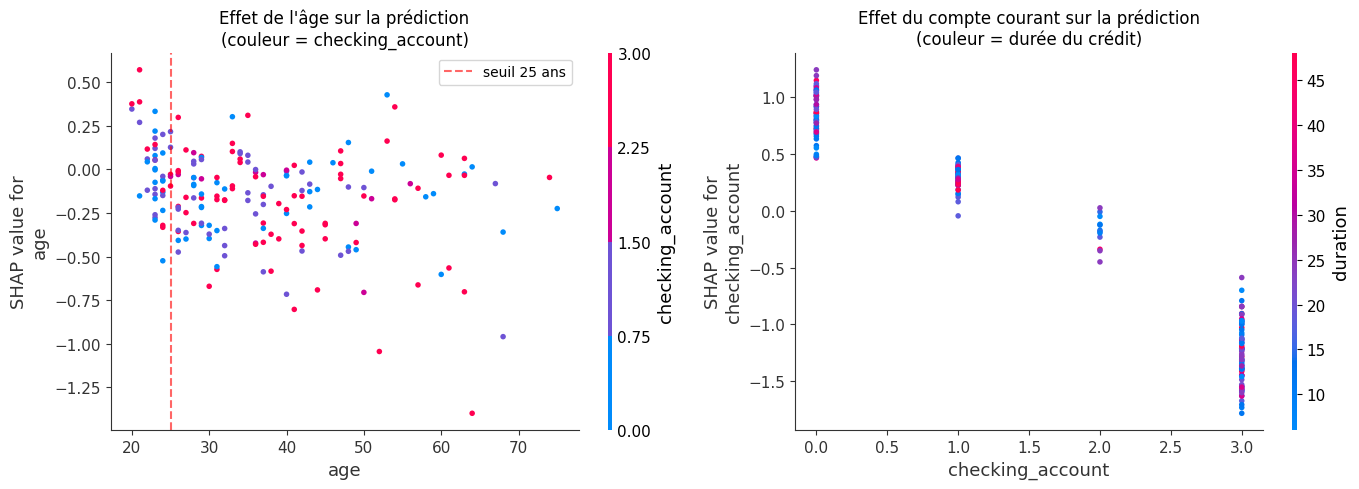

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dependence plot pour 'age'
shap.dependence_plot(
    "age", shap_values, X_test,
    feature_names=feature_cols,
    interaction_index="checking_account",  # coloré par checking_account
    ax=axes[0], show=False
)
axes[0].set_title("Effet de l'âge sur la prédiction\n(couleur = checking_account)")
axes[0].axvline(25, color="red", linestyle="--", alpha=0.6, label="seuil 25 ans")
axes[0].legend()

# Dependence plot pour 'checking_account'
shap.dependence_plot(
    "checking_account", shap_values, X_test,
    feature_names=feature_cols,
    interaction_index="duration",
    ax=axes[1], show=False
)
axes[1].set_title("Effet du compte courant sur la prédiction\n(couleur = durée du crédit)")

plt.tight_layout()
plt.show()

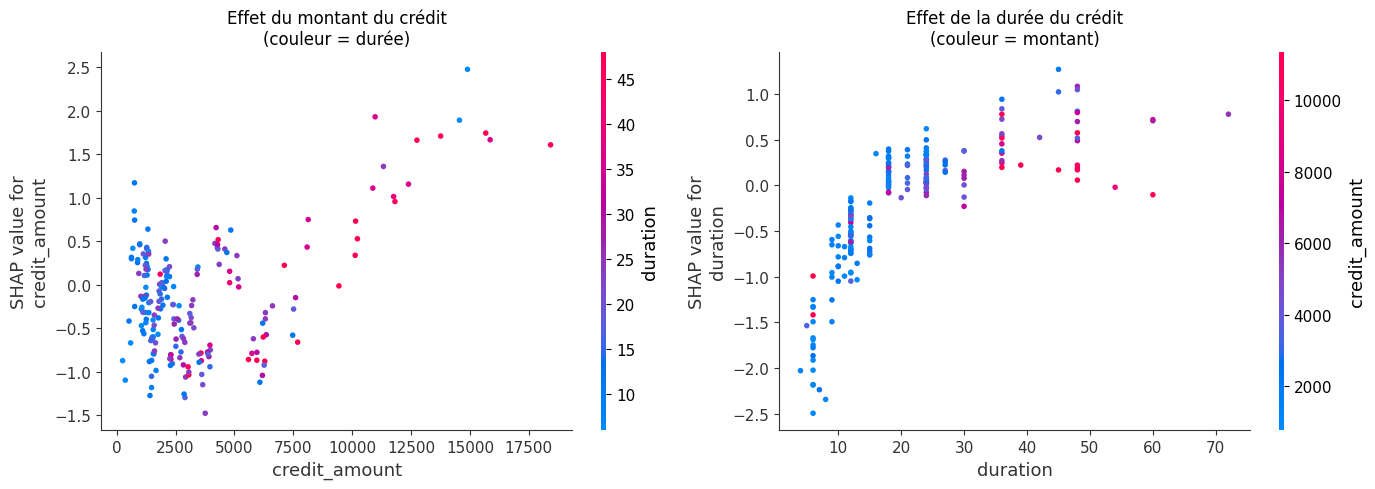

In [9]:
# Dependence pour credit_amount et duration (les deux prochaines features importantes)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap.dependence_plot(
    "credit_amount", shap_values, X_test,
    feature_names=feature_cols, interaction_index="duration",
    ax=axes[0], show=False
)
axes[0].set_title("Effet du montant du crédit\n(couleur = durée)")

shap.dependence_plot(
    "duration", shap_values, X_test,
    feature_names=feature_cols, interaction_index="credit_amount",
    ax=axes[1], show=False
)
axes[1].set_title("Effet de la durée du crédit\n(couleur = montant)")

plt.tight_layout()
plt.show()

## 8. Lien entre SHAP et Équité

**Question centrale** : le modèle utilise-t-il implicitement le genre et l'âge pour ses prédictions, et si oui, dans quelle direction ?

On mesure :
1. La SHAP value moyenne de `age` et `personal_status_sex` **par groupe sensible** : un écart montre que le modèle traite différemment les groupes
2. La distribution des SHAP values totales par groupe, pour comparer qui reçoit globalement plus de prédictions positives

In [6]:
# SHAP values des features sensibles par groupe
idx_age    = feature_cols.index("age")
idx_sex    = feature_cols.index("personal_status_sex")

df_shap = pd.DataFrame({
    "gender":         sensitive_test["gender"],
    "age_group":      sensitive_test["age_group"],
    "shap_age":       shap_values[:, idx_age],
    "shap_sex":       shap_values[:, idx_sex],
    "shap_total":     shap_values.sum(axis=1),
    "predicted_proba":y_proba,
})

print("=== SHAP value moyenne de 'age' par groupe d'âge ===")
print(df_shap.groupby("age_group")["shap_age"].agg(["mean", "std"]).round(4))

print("\n=== SHAP value moyenne de 'personal_status_sex' par genre ===")
print(df_shap.groupby("gender")["shap_sex"].agg(["mean", "std"]).round(4))

print("\n=== SHAP total moyen (score de risque net) par groupe ===")
print(df_shap.groupby("gender")["shap_total"].mean().round(4))
print(df_shap.groupby("age_group")["shap_total"].mean().round(4))

=== SHAP value moyenne de 'age' par groupe d'âge ===
                 mean     std
age_group                    
Jeune (<25)    0.0018  0.2328
Senior (>=25) -0.1905  0.2678

=== SHAP value moyenne de 'personal_status_sex' par genre ===
          mean     std
gender                
Femme   0.1783  0.1047
Homme  -0.1365  0.1828

=== SHAP total moyen (score de risque net) par groupe ===
gender
Femme   -1.0182
Homme   -1.4335
Name: shap_total, dtype: float32
age_group
Jeune (<25)     -0.5810
Senior (>=25)   -1.4826
Name: shap_total, dtype: float32


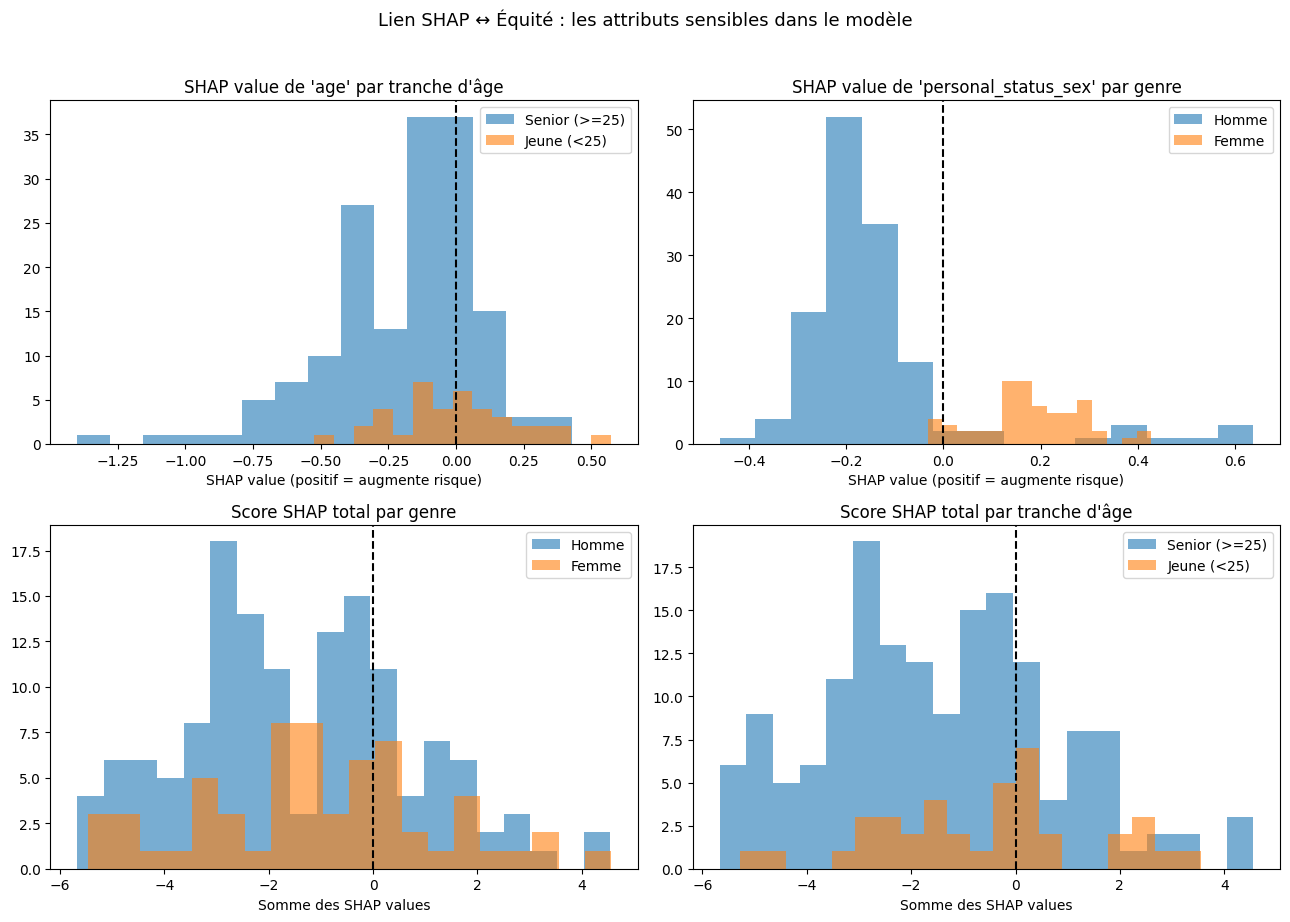

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Distribution des SHAP values de 'age' par tranche d'âge
for group in df_shap["age_group"].unique():
    mask = df_shap["age_group"] == group
    axes[0, 0].hist(df_shap.loc[mask, "shap_age"], bins=15, alpha=0.6, label=group)
axes[0, 0].axvline(0, color="black", linestyle="--")
axes[0, 0].set_title("SHAP value de 'age' par tranche d'âge")
axes[0, 0].set_xlabel("SHAP value (positif = augmente risque)")
axes[0, 0].legend()

# Distribution des SHAP values de 'personal_status_sex' par genre
for group in df_shap["gender"].unique():
    mask = df_shap["gender"] == group
    axes[0, 1].hist(df_shap.loc[mask, "shap_sex"], bins=15, alpha=0.6, label=group)
axes[0, 1].axvline(0, color="black", linestyle="--")
axes[0, 1].set_title("SHAP value de 'personal_status_sex' par genre")
axes[0, 1].set_xlabel("SHAP value (positif = augmente risque)")
axes[0, 1].legend()

# SHAP total par groupe (genre)
for group in df_shap["gender"].unique():
    mask = df_shap["gender"] == group
    axes[1, 0].hist(df_shap.loc[mask, "shap_total"], bins=20, alpha=0.6, label=group)
axes[1, 0].axvline(0, color="black", linestyle="--")
axes[1, 0].set_title("Score SHAP total par genre")
axes[1, 0].set_xlabel("Somme des SHAP values")
axes[1, 0].legend()

# SHAP total par groupe (âge)
for group in df_shap["age_group"].unique():
    mask = df_shap["age_group"] == group
    axes[1, 1].hist(df_shap.loc[mask, "shap_total"], bins=20, alpha=0.6, label=group)
axes[1, 1].axvline(0, color="black", linestyle="--")
axes[1, 1].set_title("Score SHAP total par tranche d'âge")
axes[1, 1].set_xlabel("Somme des SHAP values")
axes[1, 1].legend()

plt.suptitle("Lien SHAP / Équité : les attributs sensibles dans le modèle", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Discussion

### Ce que révèle l'analyse SHAP

1. **Features les plus importantes** : `checking_account` (0.82), `credit_amount` (0.56), `duration` (0.54), `credit_history` (0.40). Ce sont les déterminants économiques du risque de crédit, cohérent avec la logique métier. `age` arrive en 9e position (0.23), ce qui signifie que l'âge joue un rôle secondaire dans la prédiction par rapport aux variables financières.

2. **Effet de l'âge** : la SHAP value moyenne de `age` est de +0.002 pour les jeunes (<25) contre −0.19 pour les seniors (≥25). Autrement dit, le modèle considère les jeunes comme légèrement plus risqués via cette feature, ce qui explique directement la disparité DPD observée en Tâche 2 (DPD âge = 0.23).

3. **Effet du genre** (`personal_status_sex`) : la SHAP value moyenne est de +0.18 pour les femmes contre −0.14 pour les hommes. Le modèle associe donc systématiquement le fait d'être femme à un risque plus élevé via cette feature, ce qui constitue une disparité directe.

4. **Score SHAP total** : la somme des SHAP values est en moyenne de −1.02 pour les femmes contre −1.43 pour les hommes (plus proche de zéro = plus risqué). L'écart est encore plus marqué pour l'âge : −0.58 pour les jeunes contre −1.48 pour les seniors. Les jeunes et les femmes sont globalement vus comme plus risqués par le modèle, ce qui correspond au mécanisme sous-jacent des disparités mesurées par DPD et EOD en Tâche 2.

### Limites
- Les SHAP values expliquent le **comportement du modèle**, pas la **vérité terrain**. Un biais dans les données entraîne un biais dans les SHAP values.
- `personal_status_sex` encode à la fois le statut marital et le genre, donc les SHAP values capturent un effet mixte.